In [1]:
import sys
from pathlib import Path

# notebook file -> parent folder (adjust parents[n] if needed)
repo_root = Path.cwd().resolve().parent
sys.path.insert(0, str(repo_root))

In [2]:
import yfinance as yf
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [3]:
import yfinance as yf
import pandas as pd
from pathlib import Path
from typing import Callable
from quantix.data import download_stock_data, add_rolling_features

##define a class that represents a stock and has methods to download, load, and have a signal to buy or sell
## read up on pydantic and dataclasses to make this better

class Stock:
    def __init__(self, ticker: str, start: str, end: str, window: int = 20, path: str = "../data"):
        self.ticker = ticker
        self.start = start
        self.end = end
        df = download_stock_data(self.ticker, self.start, self.end, should_save=False)
        df["Return"] = df["Close"].pct_change()
        self.data = add_rolling_features(df, window)
        
        self.path = path
        print(f'Stock class initialized for ticker {ticker} with data path {path}')

    def plot_data(self, show_signal: bool = False):
        plt.figure(figsize=(14, 7))
        plt.plot(self.data.index, self.data["Return"], label="Return", color="blue")
        plt.plot(self.data.index, self.data["rolling_mean"], label="Rolling Mean", color="orange")
        plt.plot(self.data.index, self.data["rolling_std"], label="Rolling Std", color="red")
        
        # if show_signal:
        #     buy_signals = self.data[self.data["Signal"] == 1]
        #     sell_signals = self.data[self.data["Signal"] == -1]
        #     plt.scatter(buy_signals.index, buy_signals["Return"], label="Buy Signal", marker="^", color="green")
        #     plt.scatter(sell_signals.index, sell_signals["Return"], label="Sell Signal", marker="v", color="red")
        plt.title(f"{self.ticker} Returns and Rolling Mean")
        plt.xlabel("Date")
        plt.ylabel("Value")
        plt.legend()
        plt.grid()
        plt.show()


In [4]:
ticker = "AAPL"
start = "2022-01-01"
end = "2023-03-01"
aapl = Stock("AAPL", start=start, end=end)

[*********************100%***********************]  1 of 1 completed

Data fetched successfully for ticker AAPL from 2022-01-01 to 2023-03-01.
Stock class initialized for ticker AAPL with data path ../data


In [5]:
aapl.data.head()

Price,Open,High,Low,Close,Volume,Return,rolling_mean,rolling_std
Date,,,,,,,,
2022-01-03,174.013387,178.955006,173.895967,178.103668,104487900,NaN,NaN,NaN
2022-01-04,178.710386,179.013730,175.275708,175.843262,99310400,-0.012692,NaN,NaN
2022-01-05,175.755209,176.303187,170.891874,171.165863,94537600,-0.026600,NaN,NaN
2022-01-06,168.993506,171.537711,167.956258,168.308533,96904000,-0.016693,NaN,NaN
2022-01-07,169.179402,170.402574,167.359321,168.474854,86709100,0.000988,NaN,NaN


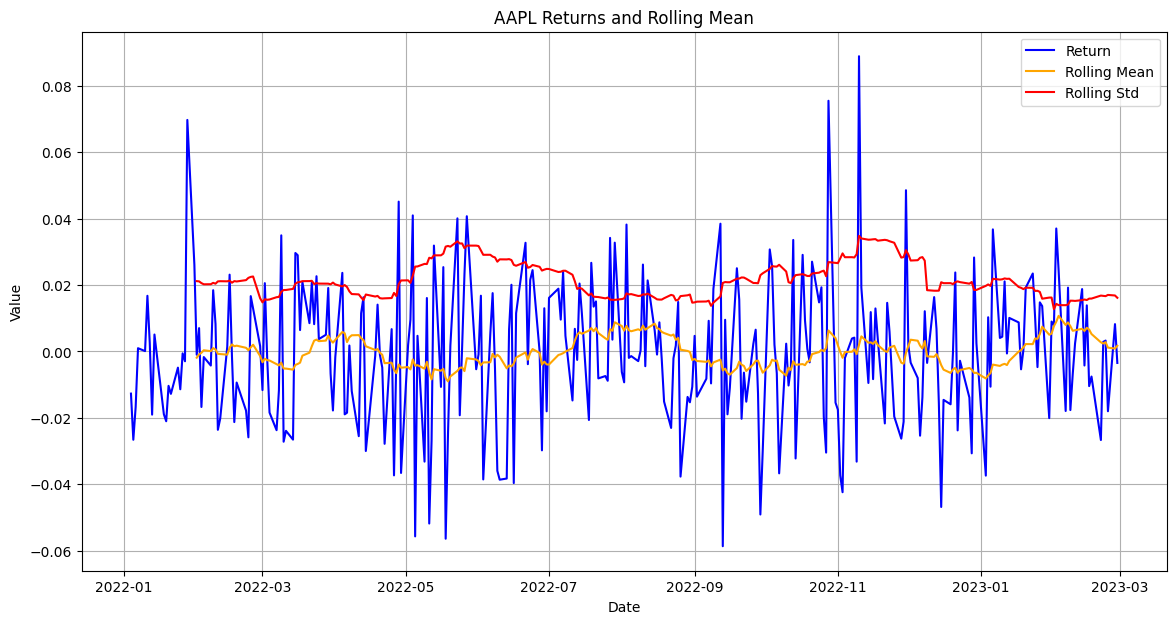

In [6]:
aapl.plot_data(show_signal=True)

## Key rule

Any strategy must implement generate_signal(row).

In [7]:
# class DummyStrategy:
#     def generate_signal(self, row):
#         return "SELL"

In [8]:
def z_score(row: dict) -> float:
    if row["rolling_std"] == 0:
        return 0
    return (row["Return"] - row["rolling_mean"]) / row["rolling_std"] if row["rolling_std"] != 0 else 0

def generate_signal(row: dict, threshold: float) -> int:
    if row["z_score"] < -threshold:
        return 1
    elif row["z_score"] > threshold:
        return -1
    return 0
    
class Z_Strategy:
    def __init__(self, stock: Stock, threshold:float = 2):
        self.stock = stock
        self.data = stock.data
        self.threshold = threshold
        # plot the z-score of the return with the rolling mean and std
        self.data["z_score"] = self.data.apply(z_score, axis=1)
        # Adir - make sure you understand lambda functions and the partial pattern here and why we need it
        self.data["signal"] = self.data.apply(lambda row: generate_signal(row, self.threshold), axis=1)
    
    def generate_signal(self, row):
        # refactor in future to use the z_score and threshold to generate signal
        # the apply should be part of backtest, not part of strategy since strat should generate 
        # signal per row (so can be used in backtest or live trading)
        pass     
    
    def plot_strategy(self):
        plt.figure(figsize=(14, 7))
        plt.plot(self.data.index, self.data["z_score"], label="Z-Score", color="purple")
        # add buy sell markers to graph
        buy_signals = self.data[self.data["signal"] == 1]
        sell_signals = self.data[self.data["signal"] == -1]
        plt.scatter(buy_signals.index, buy_signals["z_score"], label="Buy Signal", marker="^", color="green")
        plt.scatter(sell_signals.index, sell_signals["z_score"], label="Sell Signal", marker="v", color="red")

        plt.title(f"Z-Score of Returns")
        plt.xlabel("Date")
        plt.ylabel("Z-Score")
        plt.legend()
        plt.grid()
        plt.show()


In [9]:
strategy = Z_Strategy(aapl, threshold=2)

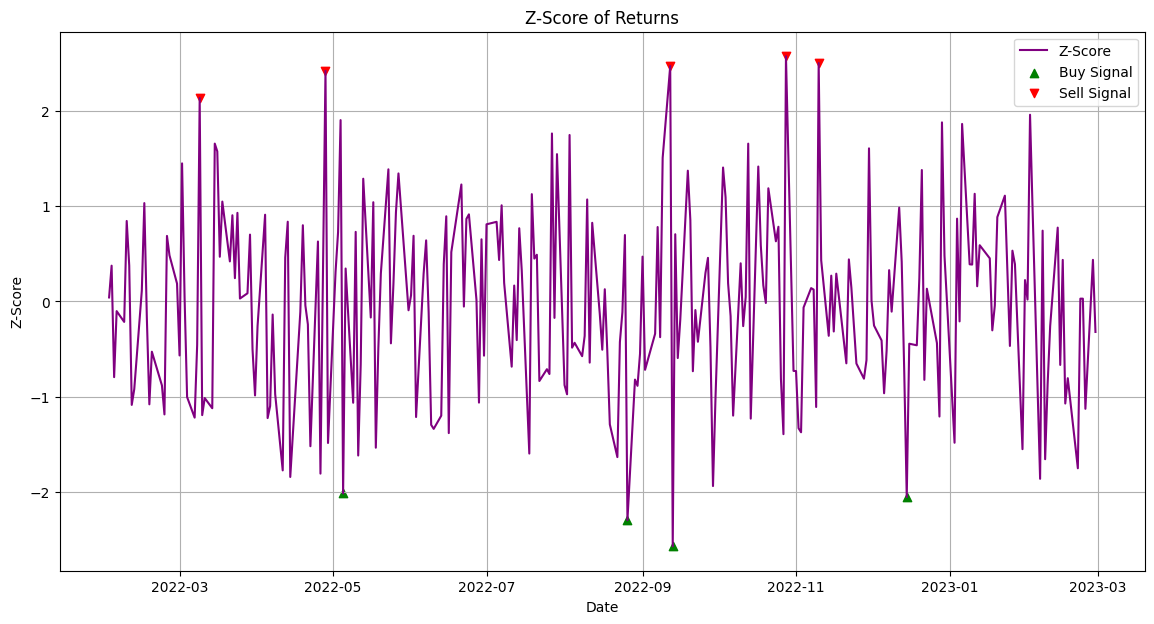

In [10]:
strategy.plot_strategy()

In [27]:
## now we want to make this a backtestable strategy, so we need to create a backtester class that takes in a strategy and a stock and runs the backtest, calculating the returns of the strategy and comparing it to a buy and hold strategy.

from numpy import cumprod


class Backtester:
    def __init__(self, strategy, initial_capital: float = 10000, percent_per_trade: float = 0.1):
        self.strategy = strategy
        self.data = strategy.data
        self.initial_capital = initial_capital
        self.percent_per_trade = percent_per_trade

    def backtest(self):
        # fields we need: strategy_return, cumulative_strategy_return, cumulative_buy_and_hold_return
        # loop through each period.
        # if the period before has a buy signal, and we are not long then we buy at the open of the current period and hold
        # if the period before has a sell and we are holding shares we sell at the close of the current period. no short sale for now.

        # lets start by looping through each period and calculating the strategy return based on the signal and the return of the stock
        self.data["strategy_return"] = 0.0
        position = 0  # 1 for long, 0 for no position
        trades = [] # will be a list of objects {"long_price": price, "shares": shares, "long_date": date, "capital_invested": capital_invested, "sale_price": price, "sale_date": date, "capital_gained": capital_gained, "return": return}
        for i in range(1, len(self.data)):
            if self.data["signal"].iloc[i-1] == 1 and position == 0:  # buy signal and not currently long
                position = 1
                # record purchase price of the stock at the open of the current period and calculate the number of shares we can buy with our initial capital and percent per trade
                purchase_price = self.data["Open"].iloc[i]
                shares_to_buy = (self.initial_capital * self.percent_per_trade) // purchase_price
                # add a row to trades list with the details of the trade (buy/sell, price, shares, date)
                trades.append({"long_price": purchase_price, "shares": shares_to_buy, "long_date": self.data.index[i], "capital_invested": purchase_price * shares_to_buy})

            elif (self.data["signal"].iloc[i-1] == -1 and position == 1) or (i == len(self.data) - 1):  # sell signal and currently long
                position = 0
                # record sale price of the stock at the close of the current period and calculate the number of shares we can sell
                sale_price = self.data["Close"].iloc[i]
                # get last row of trades and update it with the sale details (sale price, date, capital gained/lost, return)
                trades[-1].update({"sale_price": sale_price, "sale_date": self.data.index[i], "capital_gained": (sale_price - trades[-1]["long_price"]) * trades[-1]["shares"], "return": (sale_price - trades[-1]["long_price"]) / trades[-1]["long_price"]})

            # add a long flag to data to indicate we are long for the next periods until we sell
            self.data.loc[self.data.index[i], "long"] = 1 if (position == 1) else 0

        self.trades = trades

        # calculate strategy return for each period based on the trades we made
        for trade in trades:
            # loop over the data from the long date to the sale date and set strategy return for those periods based on the return of the trade
            long_index = self.data.index.get_loc(trade["long_date"])
            sale_index = self.data.index.get_loc(trade["sale_date"])
            self.data.loc[self.data.index[long_index:sale_index], "strategy_return"] += trade["return"] / (sale_index - long_index)  # distribute return evenly across the holding period
        # calculate cumulative returns
        self.data["cumulative_strategy_return"] = (1 + self.data["strategy_return"]).cumprod() - 1
        self.data["cumulative_buy_and_hold_return"] = (1 + self.data["Return"]).cumprod() - 1

    def plot_backtest(self):
        plt.figure(figsize=(14, 7))
        plt.plot(self.data.index, self.data["cumulative_strategy_return"], label="Strategy Return", color="blue")
        plt.plot(self.data.index, self.data["cumulative_buy_and_hold_return"], label="Buy and Hold Return", color="orange")
        #add markers for long and short positions
        long_positions = self.data[self.data["long"] == 1]
        plt.scatter(long_positions.index, long_positions["cumulative_strategy_return"], label="Long Position", marker="^", color="green")
        short_positions = self.data[self.data["long"] == -1]
        plt.scatter(short_positions.index, short_positions["cumulative_strategy_return"], label="Short Position", marker="v", color="red")

        plt.title(f"Backtest of Strategy vs Buy and Hold")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return")
        plt.legend()
        plt.grid()
        plt.show()

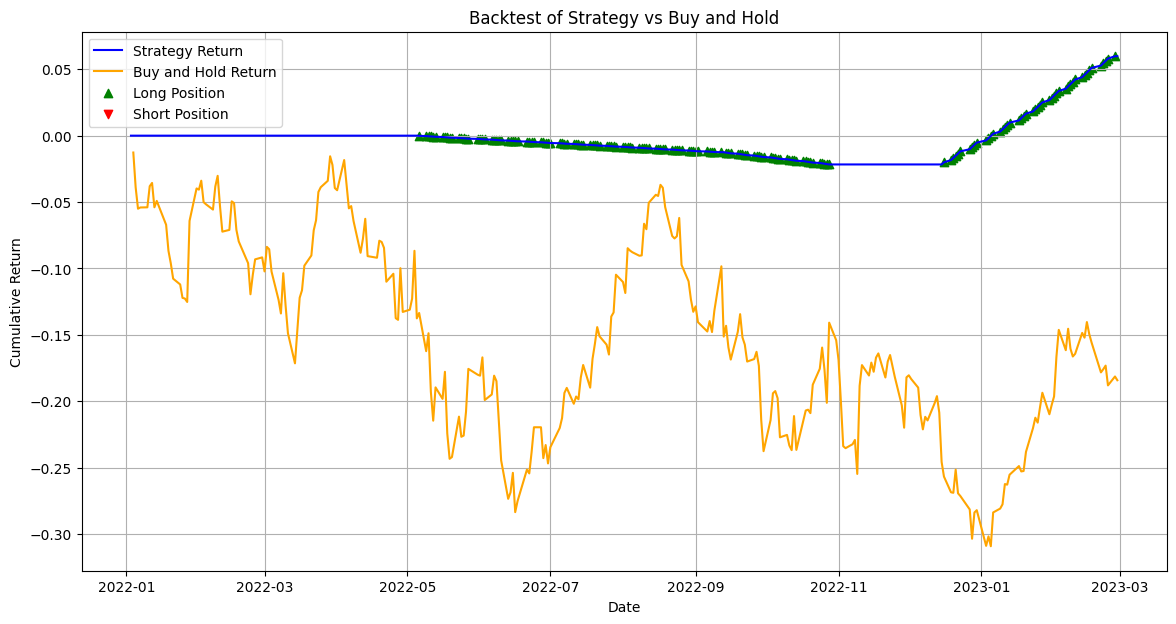

In [28]:
bt = Backtester(strategy)
bt.backtest()
bt.plot_backtest()





In [20]:
bt.trades

[{'long_price': np.float64(153.0807608024048),
  'shares': np.float64(6.0),
  'long_date': Timestamp('2022-05-06 00:00:00'),
  'capital_invested': np.float64(918.4845648144287),
  'sale_price': np.float64(151.16119384765625),
  'sale_date': Timestamp('2022-09-13 00:00:00'),
  'capital_gained': np.float64(-11.51740172849128),
  'return': np.float64(-0.012539570254855902)},
 {'long_price': np.float64(152.09465656902455),
  'shares': np.float64(6.0),
  'long_date': Timestamp('2022-09-14 00:00:00'),
  'capital_invested': np.float64(912.5679394141473),
  'sale_price': np.float64(150.66989135742188),
  'sale_date': Timestamp('2022-10-31 00:00:00'),
  'capital_gained': np.float64(-8.548591269616054),
  'return': np.float64(-0.009367621741241644)},
 {'long_price': np.float64(134.53264031194206),
  'shares': np.float64(7.0),
  'long_date': Timestamp('2022-12-16 00:00:00'),
  'capital_invested': np.float64(941.7284821835945)}]

In [ ]:
aapl.data.tail()


Price,Open,High,Low,Close,Volume,Return,rolling_mean,rolling_std,z_score,signal,strategy_return,cumulative_strategy_return,cumulative_buy_and_hold_return
Date,,,,,,,,,,,,,
2023-02-22,146.744086,147.808665,145.058514,146.783524,51011300,0.002896,0.002401,0.016760,0.029505,0,0.0,0.106706,-0.175853
2023-02-23,147.946674,148.193104,145.137382,147.266525,48394200,0.003291,0.002801,0.016677,0.029363,0,0.0,0.106706,-0.173142
2023-02-24,145.009226,145.088086,143.639077,144.614944,55469600,-0.018005,0.001160,0.017044,-1.124510,0,0.0,0.106706,-0.188029
2023-02-27,145.600685,147.039828,145.344389,145.807678,44998500,0.008248,0.000889,0.016876,0.436068,0,0.0,0.106706,-0.181333
2023-02-28,144.950102,146.951112,144.733243,145.304962,50547000,-0.003448,0.001720,0.016184,-0.319323,0,0.0,0.106706,-0.184155


## todo

in the next file and in future. backtest will incorporate
* costs
* slippage
* take profit
* stop loss
* allocation of capital across multiple stocks
* total return across all stocks
